# qiu_2026 — inspect trained-model predictions vs. recordings

Loads a trained `core_readout` checkpoint and compares its predicted neural responses against the
recorded responses, on held-out (validation/test) clips, **with the pupil shifter active**.

**How to use**
1. Set `SESSION` / `SPLIT` / `CKPT_PATH` in the config cell (defaults auto-pick the newest checkpoint).
2. Run all cells.

**Notes**
- Scoped to **one session** on purpose — loading all 10 would exceed the notebook kernel's memory.
  Change `SESSION` to any of the 10 (they all have readout heads in the trained model).
- Works on a *mid-training* checkpoint too — re-run after the job saves a newer/better one.
- The causal core trims the first `lag = T_in - T_out` frames; predictions are aligned to the
  recorded trace by dropping those leading frames from the target.


In [1]:
import os
from pathlib import Path

import hydra
import numpy as np
import torch
import matplotlib.pyplot as plt
from hydra import compose, initialize_config_dir

from openretina.utils.file_utils import get_cache_directory
from openretina.models.core_readout import load_core_readout_model

# ---- config: edit these ----
# Derived, not hard-coded: the old absolute /weka path belonged to the retired h100-ferranti
# cluster, so on Galvani it silently resolved to a non-existent directory and the checkpoint glob
# below came back empty.
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SESSION = "dynamic28188-16-3-Fluorescence-7b721b-v4a"  # single session to inspect
SPLIT = "validation"   # "validation", "train", or a test-condition name (listed a few cells down)
# Which training run to inspect. The three MEI-ensemble members, with their final
# `val_evaluation_loss` -- which is a correlation monitored with mode="max"
# (configs/training_callbacks/model_checkpoint.yaml), so *higher is better*:
#   core_readout_qiu_2026_mouse          seed 42, 0.401  (the baseline; unsuffixed, it predates the
#                                                        seed-carrying naming in run_qiu_train_seed.sh)
#   core_readout_qiu_2026_mouse_seed43   seed 43, 0.411  (best member)
#   core_readout_qiu_2026_mouse_seed44   seed 44, 0.385  (worst member)
RUN_NAME = "core_readout_qiu_2026_mouse_seed43"
CKPT_PATH = None       # None -> auto-pick the newest checkpoint under RUN_NAME
# ----------------------------

os.environ.setdefault("OPENRETINA_CACHE_DIRECTORY", str(get_cache_directory()))
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| cache:", os.environ["OPENRETINA_CACHE_DIRECTORY"])

device: cpu | cache: /home/bethge/bkr578/openretina_cache


In [2]:
# Locate the checkpoint (newest .ckpt under RUN_NAME, unless CKPT_PATH is set)
if CKPT_PATH is None:
    run_dir = REPO / "openretina_assets/runs" / RUN_NAME
    # Distinguish "wrong path" from "not trained yet" -- the two failure modes look identical
    # through an empty glob, and the first one cost a debugging round.
    assert run_dir.exists(), f"No such run directory: {run_dir}\n(is REPO right? is RUN_NAME right?)"
    ckpts = sorted(run_dir.glob("*/checkpoints/*.ckpt"), key=lambda p: p.stat().st_mtime)
    assert ckpts, f"{run_dir} has no checkpoints yet - wait for the job to finish epoch 0."
    CKPT_PATH = ckpts[-1]
CKPT_PATH = Path(CKPT_PATH)
print("Using checkpoint:", CKPT_PATH.name)
print("  full path:", CKPT_PATH)
if not CKPT_PATH.name.endswith("_final.ckpt"):
    print("  NOTE: not a *_final.ckpt -- this is a mid-training save, so training may still be running.")

Using checkpoint: epoch=49_val_evaluation_loss=0.411_final.ckpt
  full path: /mnt/lustre/work/bethge/bkr578/projects/open-retina/openretina_assets/runs/core_readout_qiu_2026_mouse_seed43/2026-08-28_11-31-55/checkpoints/epoch=49_val_evaluation_loss=0.411_final.ckpt


In [3]:
# Load the trained model (rebuilds core + readout + shifter from the checkpoint's hparams)
model = load_core_readout_model(str(CKPT_PATH), device)
model.eval()
readout_sessions = list(model.readout.keys())
print(f"{len(readout_sessions)} readout heads; shifter present: {getattr(model, 'shifter', None) is not None}")
assert SESSION in readout_sessions, f"{SESSION!r} not among trained sessions: {readout_sessions}" 

10 readout heads; shifter present: True


In [4]:
model

UnifiedCoreReadout(
  (core): <super: <class 'Core'>, <SimpleCoreWrapper object>> [SimpleCoreWrapper regularizers: gamma_hidden = 0.0|gamma_in_sparse = 0.0|gamma_input = 10|gamma_temporal = 0.01]
  
  (readout): MultiSampledGaussianReadout(
    (dynamic28188-16-3-Fluorescence-7b721b-v4a): full PointGaussianReadout (64 x 18 x 46 -> 2710) with bias
    (dynamic28188-16-5-Fluorescence-7b721b-v4a): full PointGaussianReadout (64 x 18 x 46 -> 2046) with bias
    (dynamic28188-17-2-Fluorescence-7b721b-v4a): full PointGaussianReadout (64 x 18 x 46 -> 1714) with bias
    (dynamic28188-18-4-Fluorescence-7b721b-v4a): full PointGaussianReadout (64 x 18 x 46 -> 1593) with bias
    (dynamic28188-19-9-Fluorescence-7b721b-v4a): full PointGaussianReadout (64 x 18 x 46 -> 787) with bias
    (dynamic28712-3-8-Fluorescence-7b721b-v4a): full PointGaussianReadout (64 x 18 x 46 -> 1728) with bias
    (dynamic29163-2-7-Fluorescence-7b721b-v4a): full PointGaussianReadout (64 x 18 x 46 -> 1327) with bias
    (d

# Non-test dataloaders (don't run for memory-saving reasons)

In [ ]:
# Build dataloaders for the single chosen session (compose the training config, filter sessions)
with initialize_config_dir(config_dir=str(REPO / "configs"), version_base="1.3"):
    cfg = compose(
        config_name="qiu_2026_core_readout",
        overrides=[
            f"+data_io.stimuli.sessions=[{SESSION}]",
            f"+data_io.responses.sessions=[{SESSION}]",
            f"+data_io.pupil.sessions=[{SESSION}]",
            "dataloader.batch_size=8",
        ],
    )

movies = hydra.utils.call(cfg.data_io.stimuli)
responses = hydra.utils.call(cfg.data_io.responses)
pupil = hydra.utils.call(cfg.data_io.pupil)


In [11]:
build_dataloaders = hydra.utils.instantiate(cfg.dataloader, _partial_=True,
    release_movies=True)

dataloaders = build_dataloaders(
    neuron_data_dictionary=responses,
    movies_dictionary=movies,
    pupil_dictionary=pupil,
)

splits = list(dataloaders.keys())
test_conditions = [s for s in splits if s not in ("train", "validation")]
print("splits:", ["train", "validation"], f"+ {len(test_conditions)} test-condition keys")
print("example test-condition keys:", test_conditions[:5])
assert SPLIT in dataloaders, f"SPLIT={SPLIT!r} not available. Choose from train/validation or a test key above."


#### Old version below ####

# dataloaders = hydra.utils.instantiate(
#     cfg.dataloader,
#     neuron_data_dictionary=responses,
#     movies_dictionary=movies,
#     pupil_dictionary=pupil,
# )

# splits = list(dataloaders.keys())
# test_conditions = [s for s in splits if s not in ("train", "validation")]
# print("splits:", ["train", "validation"], f"+ {len(test_conditions)} test-condition keys")
# print("example test-condition keys:", test_conditions[:5])
# assert SPLIT in dataloaders, f"SPLIT={SPLIT!r} not available. Choose from train/validation or a test key above."


Creating qiu movie dataloaders:   0%|          | 0/1 [00:00<?, ?it/s]

splits: ['train', 'validation'] + 95 test-condition keys
example test-condition keys: ['ubOIjeUGbsNAJqMPIDqU', 'ihsP/Q14/eSpxdQLR3F4', 'aedxogPGpb5IiLcjLo8c', '3wXTReOQa7mnr6Oz8aUf', '0eP/PPhAGmbJ2peZOa/E']


## Test-split repeat structure

The test split keys printed above **are** `condition_hash` strings: trials sharing a hash are repeats
of the *same* clip (verified pixel-wise — repeats are identical or differ only by rendering noise,
corr ≈ 0.999). Repeat counts are **not** uniform, and `qiu_2026_reference.md` is misleading here: it
describes only "6 distinct test clips", but the loader yields **95** conditions, of which far more
than 6 carry repeats.

Two things to keep in mind:

- **The dataloader trial-averages every condition.** `batch.targets` is the mean over repeats
  (`test_dict`), so nothing downstream of the loader can see repeat-to-repeat variability. The
  per-repeat traces survive untouched in `responses[SESSION].test_by_trial_dict`.
- **Axis order is `(reps, neurons, time)`** for qiu_2026, despite the `(trials, T_test, neurons)`
  claimed in `base_dataloader.py`'s `response_dict` docstring — `cli/eval.py` copes with a
  shape-inference heuristic. Check shapes, don't trust the docstring.

Per-repeat *predictions* are a separate problem and are **not** obtainable from these dataloaders:
`stimuli.py` averages the video and both behaviour channels over repeats, and `pupil.py` averages the
shifter's `pupil_center`, so each condition admits exactly one forward pass.


95 test conditions | 82 of them have >1 repeat

 repeats | conditions | trials
       1 |         13 |     13
       2 |         76 |    152
       7 |          2 |     14
       8 |          2 |     16
       9 |          1 |      9
      10 |          1 |     10
   total |         95 |    214

clip lengths (frames): {300: 95}


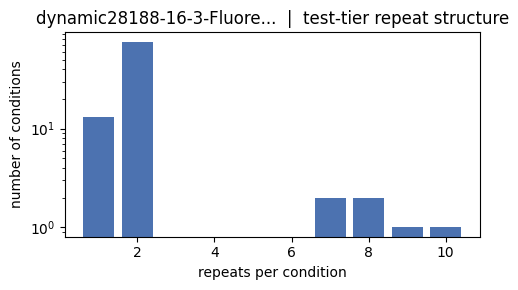

In [7]:
# --- Overview: how many repeats does each test condition have? ---
import collections

by_trial = responses[SESSION].test_by_trial_dict  # {condition_hash: (reps, neurons, time)}
n_reps = {cond: arr.shape[0] for cond, arr in by_trial.items()}
repeat_hist = collections.Counter(n_reps.values())

print(f"{len(by_trial)} test conditions | {sum(n > 1 for n in n_reps.values())} of them have >1 repeat\n")
print(" repeats | conditions | trials")
for reps, n_conds in sorted(repeat_hist.items()):
    print(f"   {reps:5d} | {n_conds:10d} | {reps * n_conds:6d}")
print(f"   total | {len(n_reps):10d} | {sum(r * k for r, k in repeat_hist.items()):6d}")

clip_lengths = collections.Counter(arr.shape[2] for arr in by_trial.values())
print("\nclip lengths (frames):", dict(clip_lengths))

plt.figure(figsize=(5, 3))
plt.bar(*zip(*sorted(repeat_hist.items())), color="#4c72b0")
plt.xlabel("repeats per condition")
plt.ylabel("number of conditions")
plt.yscale("log")  # the 1-2 repeat bulk would otherwise flatten the oracle bars to nothing
plt.title(f"{SESSION[:24]}...  |  test-tier repeat structure")
plt.tight_layout()
plt.show()


In [8]:
# --- Collect the heavily-repeated ("oracle") clips as (neurons, time, reps) ---
ORACLE_MIN_REPS = 5  # the histogram above has a clean gap: the oracle set has 7-10 reps, everything else 1-2.

oracle_conds = [cond for cond in sorted(n_reps, key=lambda c: -n_reps[c]) if n_reps[cond] >= ORACLE_MIN_REPS]

# (reps, neurons, time) -> (neurons, time, reps). Repeat counts differ per condition, so keep a dict
# rather than one stacked array (stacking would force truncation to the smallest repeat count).
oracle_responses = {cond: by_trial[cond].transpose(1, 2, 0) for cond in oracle_conds}

print(f"{len(oracle_conds)} oracle conditions (>= {ORACLE_MIN_REPS} repeats):")
for cond in oracle_conds:
    arr = oracle_responses[cond]
    # Sanity: averaging the repeats back must reproduce the trial average the dataloader serves.
    dev = np.abs(arr.mean(-1) - responses[SESSION].test_dict[cond]).max()
    print(f"  {cond}  (neurons, time, reps) = {arr.shape}   max|mean(reps) - loader avg| = {dev:.2e}")

# The 6 hashes the reference identifies as the repeated oracle clips (qiu_2026_reference.md).
REFERENCE_ORACLE_HASHES = {
    "5zQTb77qI+ig8rigx1XU",  # MadMax
    "7UETOWO5Z8aWuHDBJ2GG",  # starwars
    "GjCMo2GkJp6y5vricadg",  # finalrun
    "KXdTNAGMo1gCWz2Ge8zr",  # bigrun
    "Oup5uAZxF2G7zEJkT+ui",  # sports1m segment
    "ecUQJtcERZJGdqza1k7h",  # sports1m segment
}
print("\nmatches the 6 reference oracle hashes:", set(oracle_conds) == REFERENCE_ORACLE_HASHES)

# NOTE for FEVE / oracle metrics: these arrays are at full clip length. The causal core drops the
# first `lag` frames (18 here), so align with `oracle_responses[cond][:, lag:, :]` before comparing
# against model output, exactly as the prediction cells below do for the trial average.


6 oracle conditions (>= 5 repeats):
  GjCMo2GkJp6y5vricadg  (neurons, time, reps) = (2710, 300, 10)   max|mean(reps) - loader avg| = 0.00e+00
  ecUQJtcERZJGdqza1k7h  (neurons, time, reps) = (2710, 300, 9)   max|mean(reps) - loader avg| = 0.00e+00
  5zQTb77qI+ig8rigx1XU  (neurons, time, reps) = (2710, 300, 8)   max|mean(reps) - loader avg| = 0.00e+00
  Oup5uAZxF2G7zEJkT+ui  (neurons, time, reps) = (2710, 300, 8)   max|mean(reps) - loader avg| = 0.00e+00
  KXdTNAGMo1gCWz2Ge8zr  (neurons, time, reps) = (2710, 300, 7)   max|mean(reps) - loader avg| = 0.00e+00
  7UETOWO5Z8aWuHDBJ2GG  (neurons, time, reps) = (2710, 300, 7)   max|mean(reps) - loader avg| = 0.00e+00

matches the 6 reference oracle hashes: True


In [38]:
# Run the model over the chosen split, WITH the pupil shifter, and align to the recorded trace
dl = dataloaders[SPLIT][SESSION]
preds, targs = [], []
run_speed, pupil_size, pupil_pos = [], [], []  # behavior covariates, aligned to the output frames
lag = None
with torch.no_grad():
    for batch in dl:
        inputs = batch.inputs.to(device)               # (B, 3, T, H, W)
        pupil_center = batch.pupil_center.to(device)   # (B, 2, T)
        out = model.forward(inputs, data_key=SESSION, pupil_center=pupil_center)  # (B, T_out, N)
        targets = batch.targets                        # (B, T, N)
        lag = targets.shape[1] - out.shape[1]          # frames trimmed by the causal core
        targets = targets[:, lag:, :]
        preds.append(out.cpu().numpy().reshape(-1, out.shape[-1]))
        targs.append(targets.cpu().numpy().reshape(-1, targets.shape[-1]))
        # Behavior the model actually saw, trimmed to the output frames and flattened like the traces.
        # Input channels: 1 = pupil size, 2 = running speed (broadcast over pixels -> take any pixel).
        pupil_size.append(batch.inputs[:, 1, lag:, 0, 0].cpu().numpy().reshape(-1))
        run_speed.append(batch.inputs[:, 2, lag:, 0, 0].cpu().numpy().reshape(-1))
        # pupil_center (B, 2, T) = eye position (x, y) -> shifter input.
        pupil_pos.append(batch.pupil_center[:, :, lag:].cpu().numpy().transpose(0, 2, 1).reshape(-1, 2))

pred = np.concatenate(preds)             # (time, neurons)
targ = np.concatenate(targs)             # (time, neurons)
run_speed = np.concatenate(run_speed)    # (time,)
pupil_size = np.concatenate(pupil_size)  # (time,)
pupil_pos = np.concatenate(pupil_pos)    # (time, 2): columns = pupil x, pupil y
print(f"predicted {pred.shape}, recorded {targ.shape}, lag={lag} frames")
print(f"behavior aligned: run_speed {run_speed.shape}, pupil_size {pupil_size.shape}, pupil_pos {pupil_pos.shape}")

predicted (7896, 2710), recorded (7896, 2710), lag=18 frames
behavior aligned: run_speed (7896,), pupil_size (7896,), pupil_pos (7896, 2)


correlation  mean=0.554  median=0.548  max=0.862  n_neurons=2710


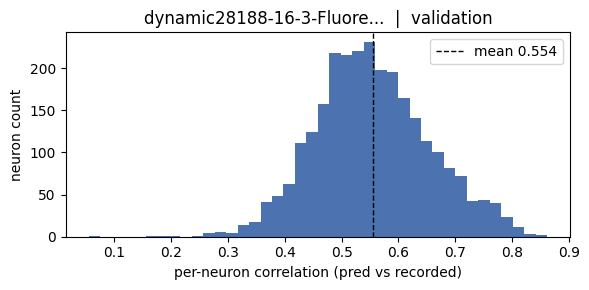

In [9]:
# Per-neuron correlation between prediction and recording
def per_neuron_corr(a, b, eps=1e-8):
    a = a - a.mean(0, keepdims=True)
    b = b - b.mean(0, keepdims=True)
    return (a * b).mean(0) / (a.std(0) * b.std(0) + eps)

c = per_neuron_corr(pred, targ)
print(f"correlation  mean={np.nanmean(c):.3f}  median={np.nanmedian(c):.3f}  "
      f"max={np.nanmax(c):.3f}  n_neurons={len(c)}")

plt.figure(figsize=(6, 3))
plt.hist(c[~np.isnan(c)], bins=40, color="#4c72b0")
plt.axvline(np.nanmean(c), color="k", ls="--", lw=1, label=f"mean {np.nanmean(c):.3f}")
plt.xlabel("per-neuron correlation (pred vs recorded)")
plt.ylabel("neuron count")
plt.title(f"{SESSION[:24]}...  |  {SPLIT}")
plt.legend()
plt.tight_layout()
plt.show()

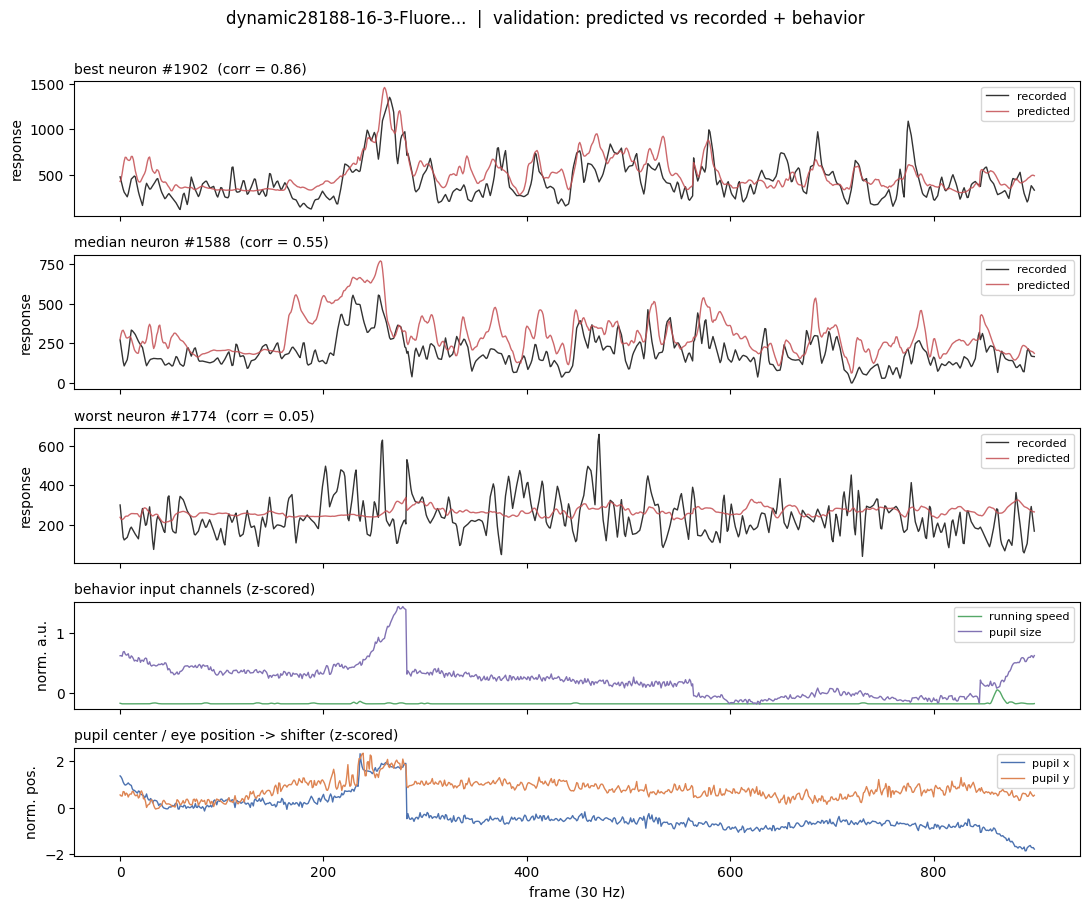

In [11]:
# Example traces: best / median / worst neurons by correlation, with the behavior covariates below.
order = np.argsort(np.nan_to_num(c, nan=-np.inf))
picks = {"best": order[-1], "median": order[len(order) // 2], "worst": order[0]}
T = min(900, pred.shape[0])  # ~30 s at 30 Hz

n_rows = len(picks) + 2  # 3 neuron traces + behavior (speed/size) + pupil position
fig, axs = plt.subplots(
    n_rows, 1, figsize=(11, 9), sharex=True,
    gridspec_kw={"height_ratios": [1] * len(picks) + [0.8, 0.8]},
)

for ax, (label, n) in zip(axs, picks.items()):
    ax.plot(targ[:T, n], lw=1.0, label="recorded", color="#333333")
    ax.plot(pred[:T, n], lw=1.0, alpha=0.85, label="predicted", color="#c44e52")
    ax.set_title(f"{label} neuron #{n}  (corr = {c[n]:.2f})", fontsize=10, loc="left")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_ylabel("response")

# Behavior input channels the model saw (z-scored): running speed + pupil size.
ax_beh = axs[len(picks)]
ax_beh.plot(run_speed[:T], lw=1.0, color="#55a868", label="running speed")
ax_beh.plot(pupil_size[:T], lw=1.0, color="#8172b3", label="pupil size")
ax_beh.set_title("behavior input channels (z-scored)", fontsize=10, loc="left")
ax_beh.legend(loc="upper right", fontsize=8)
ax_beh.set_ylabel("norm. a.u.")

# Pupil center / eye position (the shifter input), z-scored.
ax_pos = axs[len(picks) + 1]
ax_pos.plot(pupil_pos[:T, 0], lw=1.0, color="#4c72b0", label="pupil x")
ax_pos.plot(pupil_pos[:T, 1], lw=1.0, color="#dd8452", label="pupil y")
ax_pos.set_title("pupil center / eye position -> shifter (z-scored)", fontsize=10, loc="left")
ax_pos.legend(loc="upper right", fontsize=8)
ax_pos.set_ylabel("norm. pos.")

axs[-1].set_xlabel("frame (30 Hz)")
fig.suptitle(f"{SESSION[:24]}...  |  {SPLIT}: predicted vs recorded + behavior", y=1.005)
plt.tight_layout()
plt.show()

## Evaluation metrics across the 6 oracle conditions

Each oracle condition is an independent estimate of the same quantity — how well the model predicts
this session's neurons. The repeats make noise-corrected metrics available (FEVE, jackknife oracle),
so we can ask how much the answer depends on *which* clip you happen to evaluate on.

Three things to keep in mind when reading the numbers:

- **7–10 repeats is few** for estimating noise variance. Per-neuron FEVE is correspondingly noisy, and
  `feve()` clips negative values to zero — a large fraction of exactly-zero entries is expected, not a
  bug.
- **One forward pass per condition.** The loader averages stimulus, behaviour and pupil over repeats,
  so the prediction is a single trace compared against every repeat (see the section above).
- **FEVE is only interpretable where there is explainable variance.** `cli/eval.py` filters on
  `var_ratio >= 0.15` (`configs/evaluation/default.yaml`); the same cutoff is applied below, requiring
  a neuron to pass it in *all* 6 conditions so the cross-condition comparison uses one fixed
  population.


In [12]:
# --- Per-neuron metrics for every oracle condition ---
import pandas as pd

from openretina.eval.metrics import correlation_numpy, explainable_vs_total_var, feve
from openretina.eval.oracles import oracle_corr_jackknife

VAR_RATIO_CUTOFF = 0.15  # matches configs/evaluation/default.yaml


def predict_condition(cond):
    """Model prediction for one test condition -> ((time, neurons), lag) with the pupil shifter active."""
    outs, lag = [], None
    with torch.no_grad():
        for batch in dataloaders[cond][SESSION]:
            out = model.forward(
                batch.inputs.to(device), data_key=SESSION, pupil_center=batch.pupil_center.to(device)
            )
            lag = batch.targets.shape[1] - out.shape[1]  # frames trimmed by the causal core
            outs.append(out.cpu().numpy().reshape(-1, out.shape[-1]))
    return np.concatenate(outs), lag


metrics = {}
for cond in oracle_conds:
    pred_c, lag_c = predict_condition(cond)
    # (neurons, time, reps) -> (time, reps, neurons), the layout every metric below expects,
    # dropping the leading frames the causal core cannot predict.
    targ_c = oracle_responses[cond].transpose(1, 2, 0)[lag_c:]
    assert targ_c.shape[0] == pred_c.shape[0] and targ_c.shape[2] == pred_c.shape[1], (
        f"{targ_c.shape=} does not align with {pred_c.shape=}"
    )

    var_ratio, _ = explainable_vs_total_var(targ_c)
    jackknife, _ = oracle_corr_jackknife(targ_c, cut_first_n_frames=None)
    metrics[cond] = {
        "n_reps": targ_c.shape[1],
        "feve": feve(targ_c, pred_c),
        "corr": correlation_numpy(targ_c.mean(axis=1), pred_c, axis=0),
        "oracle": jackknife,
        "var_ratio": var_ratio,
    }

# One fixed neuron population for the comparison: reliable in every condition.
reliable = np.all([m["var_ratio"] >= VAR_RATIO_CUTOFF for m in metrics.values()], axis=0)
print(
    f"{reliable.sum()} / {reliable.size} neurons pass var_ratio >= {VAR_RATIO_CUTOFF} "
    f"in all {len(oracle_conds)} oracle conditions"
)

summary = pd.DataFrame(
    {
        cond: {
            "reps": m["n_reps"],
            "FEVE (median)": np.median(m["feve"][reliable]),
            "FEVE > 0 (frac)": np.mean(m["feve"][reliable] > 0),
            "corr to avg (median)": np.median(m["corr"][reliable]),
            "oracle jackknife (median)": np.median(m["oracle"][reliable]),
            "var_ratio (median)": np.median(m["var_ratio"][reliable]),
        }
        for cond, m in metrics.items()
    }
).T
summary.round(3)


528 / 2710 neurons pass var_ratio >= 0.15 in all 6 oracle conditions


,reps,FEVE (median),FEVE > 0 (frac),corr to avg (median),oracle jackknife (median),var_ratio (median)
GjCMo2GkJp6y5vricadg,10.0,0.299,0.669,0.741,0.526,0.337
ecUQJtcERZJGdqza1k7h,9.0,0.379,0.765,0.697,0.470,0.289
5zQTb77qI+ig8rigx1XU,8.0,0.043,0.525,0.613,0.436,0.265
Oup5uAZxF2G7zEJkT+ui,8.0,0.593,0.949,0.803,0.678,0.520
KXdTNAGMo1gCWz2Ge8zr,7.0,0.362,0.788,0.658,0.504,0.337
7UETOWO5Z8aWuHDBJ2GG,7.0,0.440,0.830,0.721,0.554,0.388


median across the reliable population, per condition:
  feve    0.043 - 0.593   (spread 0.550)
  corr    0.613 - 0.803   (spread 0.190)
  oracle  0.436 - 0.678   (spread 0.242)


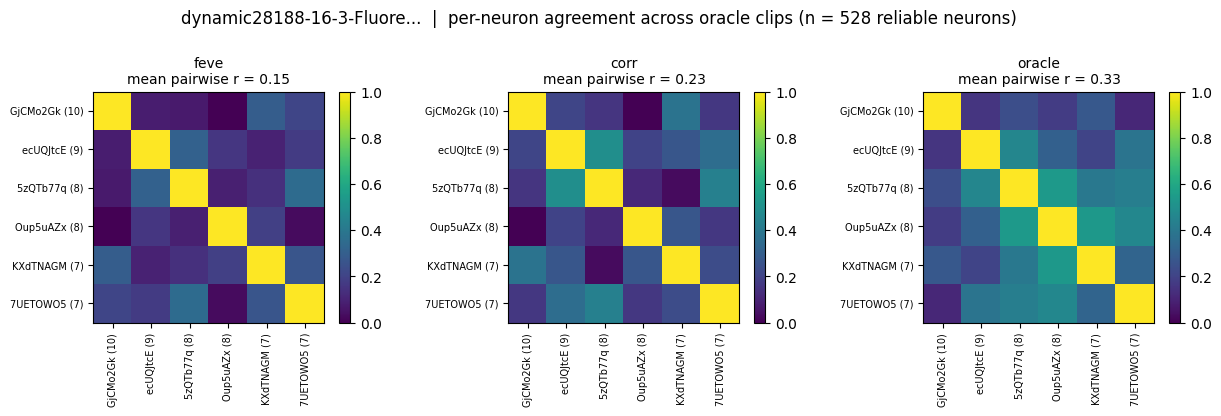

In [13]:
# --- Do the conditions agree? Two separate questions. ---
COMPARED_METRICS = ["feve", "corr", "oracle"]

# (1) Population level: does the headline number move when you swap the evaluation clip?
print("median across the reliable population, per condition:")
for key in COMPARED_METRICS:
    med = np.array([np.median(metrics[cond][key][reliable]) for cond in oracle_conds])
    print(f"  {key:7s} {med.min():.3f} - {med.max():.3f}   (spread {np.ptp(med):.3f})")

# (2) Neuron level: is a neuron that scores well on one clip the same neuron that scores well on
#     another? Correlate the per-neuron metric vectors between every pair of conditions.
labels = [f"{cond[:8]} ({metrics[cond]['n_reps']})" for cond in oracle_conds]
fig, axs = plt.subplots(1, len(COMPARED_METRICS), figsize=(4.2 * len(COMPARED_METRICS), 3.8))
for ax, key in zip(axs, COMPARED_METRICS):
    stack = np.stack([metrics[cond][key][reliable] for cond in oracle_conds])  # (conditions, neurons)
    cross = np.corrcoef(stack)
    off_diag = cross[np.triu_indices(len(oracle_conds), k=1)]
    im = ax.imshow(cross, vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(len(labels)), labels, rotation=90, fontsize=7)
    ax.set_yticks(range(len(labels)), labels, fontsize=7)
    ax.set_title(f"{key}\nmean pairwise r = {off_diag.mean():.2f}", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(
    f"{SESSION[:24]}...  |  per-neuron agreement across oracle clips "
    f"(n = {reliable.sum()} reliable neurons)",
    y=1.04,
)
plt.tight_layout()
plt.show()


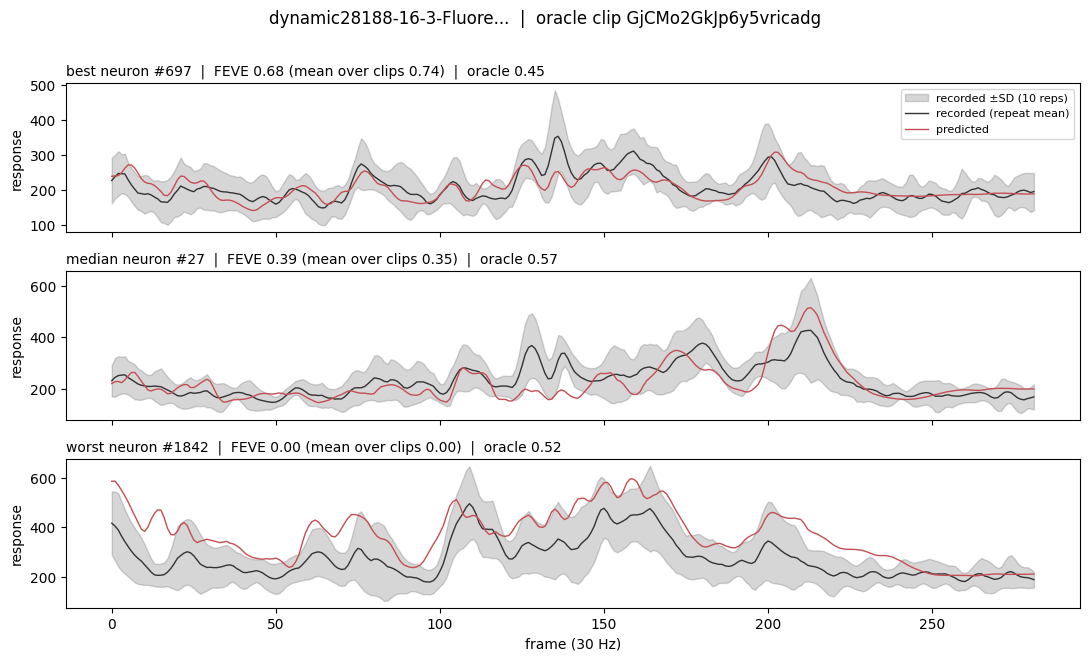

In [14]:
# --- Example neurons on the most-repeated oracle clip: repeat mean +/- SD vs prediction ---
COND = oracle_conds[0]  # oracle_conds is sorted by repeat count, so this is the best-sampled clip
pred_c, lag_c = predict_condition(COND)
targ_c = oracle_responses[COND].transpose(1, 2, 0)[lag_c:]  # (time, reps, neurons)

# Rank the reliable neurons by FEVE averaged over all 6 conditions, so the picks are not an artefact
# of whichever clip we happen to be plotting.
mean_feve = np.mean([metrics[cond]["feve"] for cond in oracle_conds], axis=0)
reliable_ids = np.flatnonzero(reliable)[np.argsort(mean_feve[reliable])]  # worst -> best
picks = {"best": reliable_ids[-1], "median": reliable_ids[len(reliable_ids) // 2], "worst": reliable_ids[0]}

frames = np.arange(targ_c.shape[0])
fig, axs = plt.subplots(len(picks), 1, figsize=(11, 6.5), sharex=True)
for ax, (label, n) in zip(axs, picks.items()):
    mean_trace = targ_c[:, :, n].mean(axis=1)
    sd_trace = targ_c[:, :, n].std(axis=1)
    ax.fill_between(
        frames, mean_trace - sd_trace, mean_trace + sd_trace,
        color="#333333", alpha=0.2, label=f"recorded ±SD ({targ_c.shape[1]} reps)",
    )
    ax.plot(frames, mean_trace, lw=1.0, color="#333333", label="recorded (repeat mean)")
    ax.plot(frames, pred_c[:, n], lw=1.0, color="#c44e52", label="predicted")
    ax.set_title(
        f"{label} neuron #{n}  |  FEVE {metrics[COND]['feve'][n]:.2f} "
        f"(mean over clips {mean_feve[n]:.2f})  |  oracle {metrics[COND]['oracle'][n]:.2f}",
        fontsize=10, loc="left",
    )
    ax.set_ylabel("response")
axs[0].legend(loc="upper right", fontsize=8)
axs[-1].set_xlabel("frame (30 Hz)")
fig.suptitle(f"{SESSION[:24]}...  |  oracle clip {COND}", y=1.01)
plt.tight_layout()
plt.show()


## Where to go next (outdated)
- **Change `SPLIT`** to one of the printed test-condition keys to inspect a specific held-out clip
  (test clips are evaluated as whole 300/450-frame clips).
- **Compare across sessions**: rerun with a different `SESSION` (memory-safe, one at a time).
- **Oracle / FEVE**: the repeated "oracle" test clips have multiple repeats, enabling explainable-variance
  metrics (`openretina.eval.metrics.feve`, `openretina.eval.oracles.oracle_corr_jackknife`) — see
  `openretina/cli/eval.py` for the full metric suite.
- **Sanity on the shifter**: rerun the prediction cell passing `pupil_center=None` to `model.forward`
  and compare correlations to see how much the pupil shifter contributes.
